In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


sns.set(style = 'white')

seed = 42

In [2]:
train_df = pd.read_csv(r"C:\Users\oluwa\OneDrive\Documents\Data Science_ML\Titanic Challenge\titanic\train.csv")
test_df = pd.read_csv(r"C:\Users\oluwa\OneDrive\Documents\Data Science_ML\Titanic Challenge\titanic\test.csv")

# Feature engineering

In [3]:
title_map = {
    'Mr': 'Mr',
    'Miss': 'Miss',
    'Mrs': 'Mrs',
    'Master': 'Master',
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs',
    'Dr': 'Rare',
    'Rev': 'Rare',
    'Major': 'Rare',
    'Col': 'Rare',
    'Capt': 'Rare',
    'Sir': 'Royalty',
    'Lady': 'Royalty',
    'Don': 'Royalty',
    'Jonkheer': 'Royalty',
    'the Countess': 'Royalty'
}

def add_features(df):

    df = df.copy()

    # Family size and IsAlone
    df['FamSize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamSize'] == 1).astype(int)

    # Has Cabin
    df['HasCabin'] = df['Cabin'].notna().astype(int)

    # Title extraction
    df['Title'] = df['Name'].str.extract(r',\s*([^\.]*)\s*\.')[0].str.strip()

    df['Title_Group'] = df['Title'].map(title_map)

    # Deck
    df['Deck'] = df['Cabin'].fillna('Unknown').astype(str).str[0]

    #Fare per person
    df['FarePerPerson'] = df['Fare']/df['FamSize']

    # Ticket group size
    ticket_count = df['Ticket'].value_counts()
    df['TicketGroupSize'] = df['Ticket'].map(ticket_count)

    return df


In [4]:
train_df = add_features(train_df)
test_df = add_features(test_df)

In [5]:
target = 'Survived'

drop_cols = ['PassengerId', 'Name', 'Ticket', 'Title', 'Cabin']

num_features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamSize', 'FarePerPerson']
cat_features = ['Sex', 'Title_Group', 'Deck', 'Embarked', 'HasCabin']
features = num_features + cat_features

In [6]:
X = train_df[features]
y = train_df[target]

X_train, X_valid, y_train, y_valid = train_test_split(X, y, stratify = y, test_size = 0.3, random_state = seed)


In [7]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False, drop = 'first'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
])

# Logistic Regression Model

In [8]:
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(random_state = seed, max_iter = 100))
])

lr_pipe.fit(X_train, y_train)

print('LR training accuracy', lr_pipe.score(X_train, y_train))
print('LR validation accuracy: ', lr_pipe.score(X_valid, y_valid))


LR training accuracy 0.8362760834670947
LR validation accuracy:  0.8171641791044776


In [9]:
num_features_trans = num_features

cat_features_trans = lr_pipe.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .named_steps['encoder'] \
    .get_feature_names_out(cat_features)

all_features = np.concatenate([num_features_trans, cat_features_trans])

feat_imp = pd.DataFrame(
    lr_pipe.named_steps['clf'].coef_[0],
    index=all_features,
    columns=['coef']
).reset_index().rename(columns={'index':'feature'}).sort_values(by='coef', ascending=False)


In [10]:
feat_imp

,feature,coef
15,Deck_D,0.831819
10,Title_Group_Mrs,0.729310
16,Deck_E,0.721611
23,HasCabin_1,0.494309
17,Deck_F,0.377690
4,Fare,0.289907
21,Embarked_Q,0.272896
3,Parch,-0.100123
6,FarePerPerson,-0.110401
8,Title_Group_Miss,-0.157669


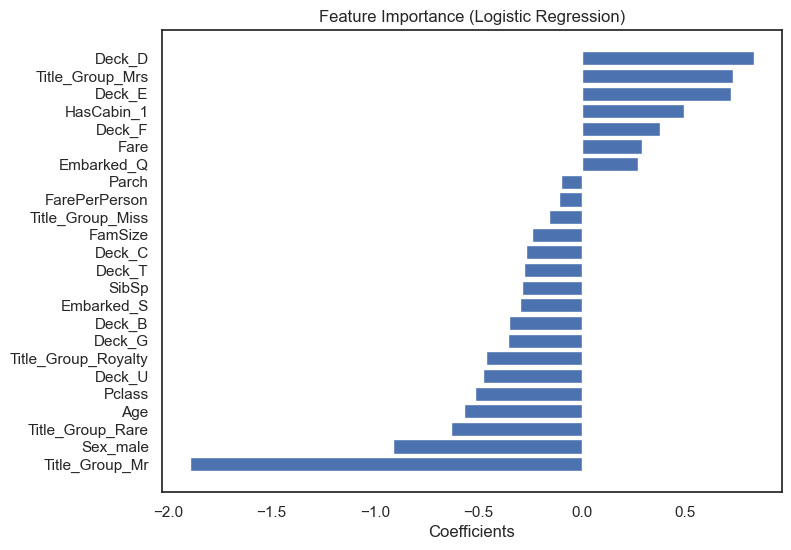

In [11]:
feat_imp.columns = ['Features', 'Importance']

plt.figure(figsize = (8,6))
plt.barh(feat_imp['Features'], feat_imp['Importance'])
plt.xlabel('Coefficients')
plt.title('Feature Importance (Logistic Regression)')
plt.gca().invert_yaxis()
plt.show()

# Comparing SVC and Random Forest models

In [12]:
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', SVC(random_state = seed))
])

param_grid = [
    {
        'clf': [SVC(random_state = seed)],
        'clf__kernel' : ['rbf', 'linear'],
        'clf__C' : [0.1, 1, 10, 100],
        'clf__gamma' : ['scale', 0.01, 0.1]
    },
    {
        'clf' : [RandomForestClassifier(random_state = seed)],
        'clf__n_estimators' : [100, 200],
        'clf__max_depth' : [None, 5, 10],
        'clf__min_samples_split' : [2, 5]
    }
]

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = seed)

grid = GridSearchCV(pipe, param_grid, cv = cv, n_jobs = -1)
grid.fit(X_train, y_train)

print('Best params:', grid.best_params_)
print('Best CV score:', grid.best_score_)

Best params: {'clf': RandomForestClassifier(random_state=42), 'clf__max_depth': 10, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
Best CV score: 0.8411225806451613


In [13]:
best_model = grid.best_estimator_
val_pred = best_model.predict(X_valid)
print('Validation accuracy (best model):', accuracy_score(y_valid, val_pred))
print(classification_report(y_valid, val_pred))

Validation accuracy (best model): 0.8134328358208955
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       165
           1       0.80      0.69      0.74       103

    accuracy                           0.81       268
   macro avg       0.81      0.79      0.80       268
weighted avg       0.81      0.81      0.81       268



In [14]:
best_model.fit(X,y)
test_pred = best_model.predict(test_df[features])
submission = pd.DataFrame({'PassengerId':test_df['PassengerId'], 'Survived':test_pred})

In [15]:
submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
